# Debugging digitisation

Some weirdness with the digi/reco that is causing crashes.

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx
import awkward as ak

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks")
from loading_utils import load_root_file, load_hepmc_event

## Roadmap

1. Load an ACTS particles file
2. Examine primary vertices...


## Loading

Is the edm4hep file correctly loading?

In [2]:
edm_input_file = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/3/edm4hep.root"
event = EDM4hepEvent(edm_input_file, event_index=0)

Loading event 0 from /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/3/edm4hep.root...
  Loaded 779885 particles.
  Loaded 219726 tracker hits.
  Loaded 1114860 calo hits and 5354637 contributions.


In [4]:
# input_particles_file = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/3/particles.root"
# digi_particles = load_root_file(input_particles_file, event_id=0, ignore_variable_columns=False)
# digi_particles = digi_particles.reset_index(drop=True)

# input_simhits_file = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/3/simhits.root"
# simhits = load_root_file(input_simhits_file, event_id=0)
# simhits = simhits.reset_index(drop=True)

input_digihits_file = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/3/measurements.root"
digihits = load_root_file(input_digihits_file, event_id=0)
digihits = digihits.reset_index(drop=True)

In [5]:
digihits

,event_nr,volume_id,layer_id,surface_id,extra_id,rec_loc0,rec_loc1,rec_time,var_loc0,var_loc1,...,true_y,true_z,true_incident_phi,true_incident_theta,residual_loc0,residual_loc1,residual_time,pull_loc0,pull_loc1,pull_time
0,0,16,4,1,1,-9.049526,4.320752,NaN,0.000208,0.000208,...,9.049156,-1515.599976,-2.189626,-2.557648,NaN,NaN,NaN,NaN,NaN,NaN
1,0,16,4,1,1,-11.775000,13.708282,NaN,0.000208,0.000208,...,11.776984,-1515.599976,-1.398139,-2.239608,NaN,NaN,NaN,NaN,NaN,NaN
2,0,16,4,1,1,6.825001,-21.625000,NaN,0.000208,0.000208,...,-6.817534,-1515.599976,-1.371504,-1.755120,NaN,NaN,NaN,NaN,NaN,NaN
3,0,16,4,1,1,-7.875000,-32.916176,NaN,0.000208,0.000208,...,7.854569,-1515.599976,-1.554390,-1.106851,NaN,NaN,NaN,NaN,NaN,NaN
4,0,16,4,1,1,-3.925000,-5.025000,NaN,0.000208,0.000208,...,3.928653,-1515.599976,-1.569499,-1.523981,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219720,0,30,12,191,2,-37.028572,-52.000000,NaN,0.000612,225.333328,...,881.039795,3004.500000,-1.781329,-1.239837,NaN,NaN,NaN,NaN,NaN,NaN
219721,0,30,12,192,2,29.828575,-52.000000,NaN,0.000612,225.333328,...,861.428955,3009.500000,-1.743614,-0.585216,NaN,NaN,NaN,NaN,NaN,NaN
219722,0,30,12,192,2,36.600002,-52.000000,NaN,0.000612,225.333328,...,854.031250,3009.500000,0.822327,0.622118,NaN,NaN,NaN,NaN,NaN,NaN
219723,0,30,12,192,2,47.957146,0.000000,NaN,0.000612,225.333328,...,907.282104,3009.500000,1.051787,1.667384,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
digihits.columns

Index(['event_nr', 'volume_id', 'layer_id', 'surface_id', 'extra_id',
       'rec_loc0', 'rec_loc1', 'rec_time', 'var_loc0', 'var_loc1', 'var_time',
       'rec_x', 'rec_y', 'rec_z', 'clus_size', 'clus_size_loc0',
       'clus_size_loc1', 'true_loc0', 'true_loc1', 'true_phi', 'true_theta',
       'true_qop', 'true_time', 'true_x', 'true_y', 'true_z',
       'true_incident_phi', 'true_incident_theta', 'residual_loc0',
       'residual_loc1', 'residual_time', 'pull_loc0', 'pull_loc1',
       'pull_time'],
      dtype='object')

In [10]:
digihits['r'] = np.sqrt(digihits.rec_x**2 + digihits.rec_y**2)
long_strip_hits = digihits[(digihits.volume_id == 28) | (digihits.volume_id == 30)]

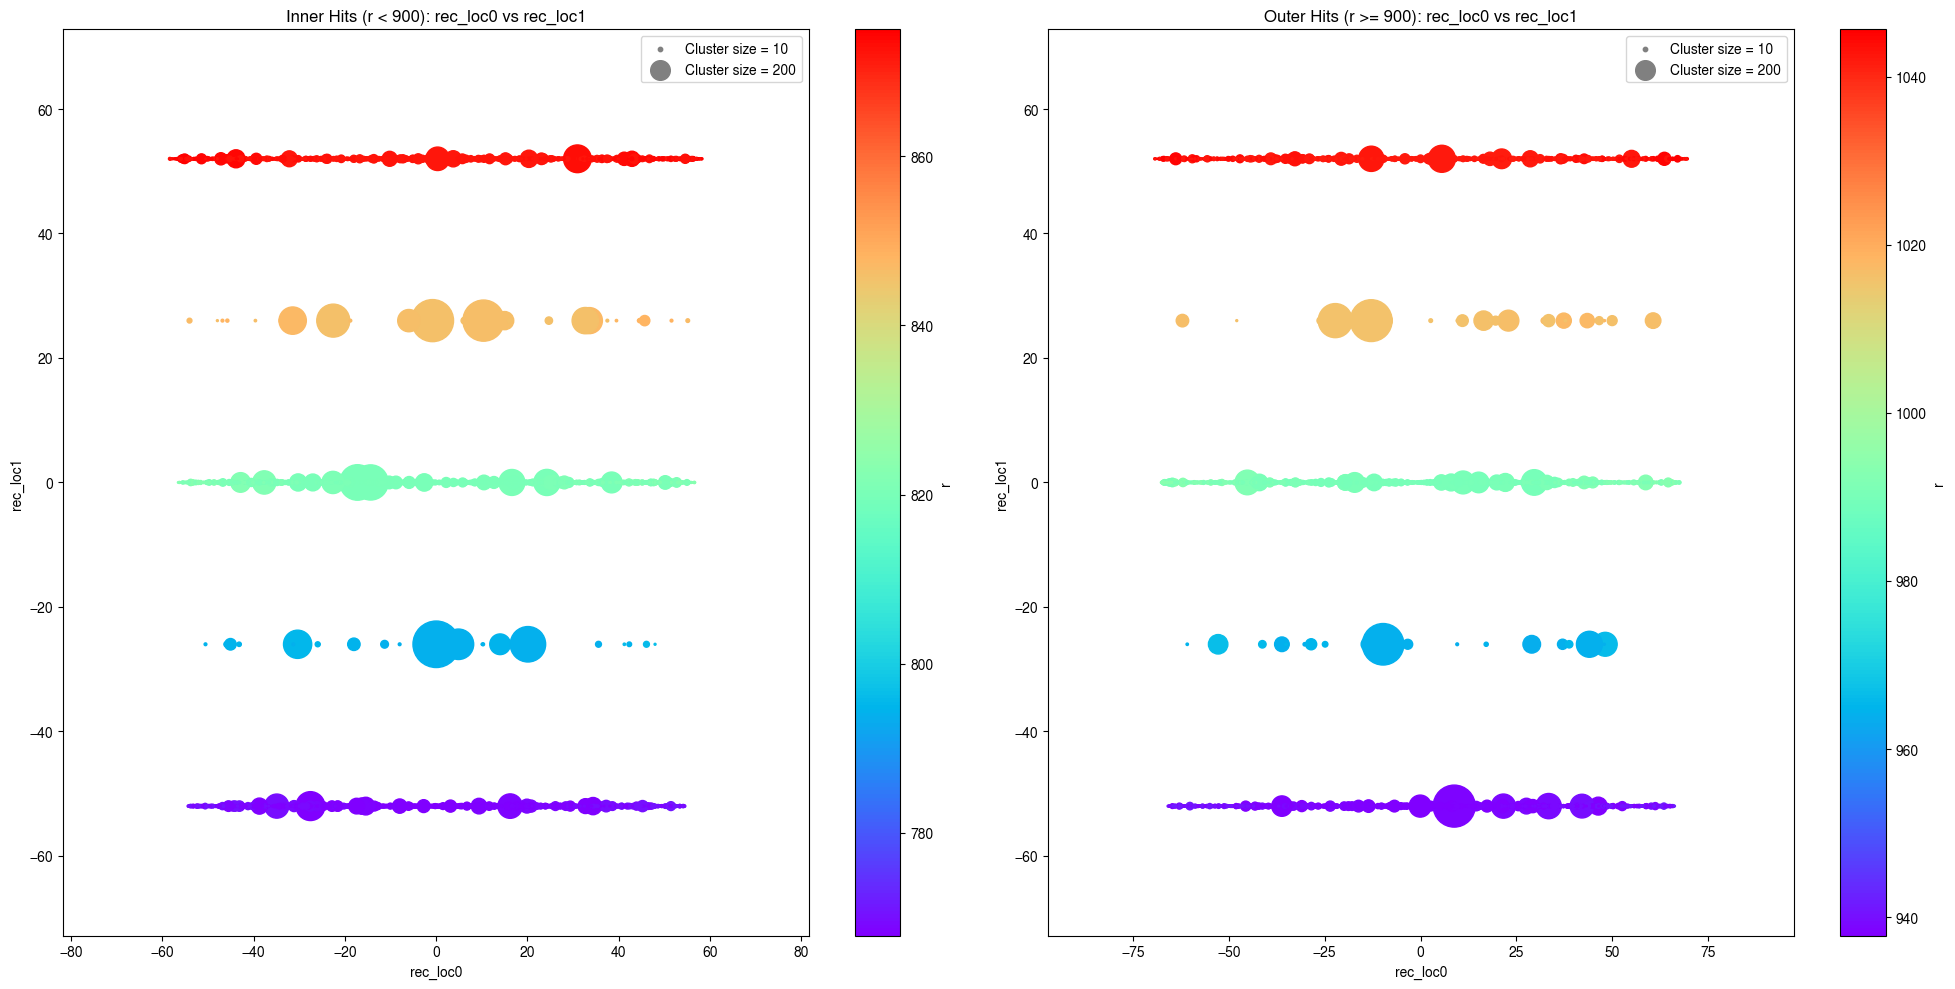

In [22]:
plt.figure(figsize=(20, 10))

# Split long strip hits by r = 900 threshold
inner_hits = long_strip_hits[long_strip_hits.r < 900]
outer_hits = long_strip_hits[long_strip_hits.r >= 900]

# Subplot for inner hits (r < 900)
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(inner_hits.rec_loc0, inner_hits.rec_loc1, c=inner_hits.r, cmap='rainbow', s=inner_hits.clus_size)
plt.colorbar(scatter1, label='r')
plt.xlabel('rec_loc0')
plt.ylabel('rec_loc1')
plt.title('Inner Hits (r < 900): rec_loc0 vs rec_loc1')
plt.margins(0.2)

# Add legend showing two example cluster sizes
legend_elements = [
    plt.scatter([], [], s=10, c='gray', label='Cluster size = 10'),
    plt.scatter([], [], s=200, c='gray', label='Cluster size = 200')
]
plt.legend(handles=legend_elements, loc='upper right')

# Subplot for outer hits (r >= 900)
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(outer_hits.rec_loc0, outer_hits.rec_loc1, c=outer_hits.r, cmap='rainbow', s=outer_hits.clus_size)
plt.colorbar(scatter2, label='r')
plt.xlabel('rec_loc0')
plt.ylabel('rec_loc1')
plt.title('Outer Hits (r >= 900): rec_loc0 vs rec_loc1')
plt.margins(0.2)

# Add legend showing two example cluster sizes
legend_elements = [
    plt.scatter([], [], s=10, c='gray', label='Cluster size = 10'),
    plt.scatter([], [], s=200, c='gray', label='Cluster size = 200')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()


In [6]:
simhits

,event_id,geometry_id,particle_id,tx,ty,tz,tt,tpx,tpy,tpz,...,deltapx,deltapy,deltapz,deltae,index,volume_id,boundary_id,layer_id,approach_id,sensitive_id
0,0,1152921779484754177,423338364972957809,80.320984,9.049156,-1515.599976,1123.487915,-0.037847,0.017811,-0.025010,...,0.0,0.0,0.0,-0.000068,-1,16,0,4,0,1
1,0,1152921779484754177,594475150812905496,89.708481,11.776984,-1515.599976,1218.989014,-0.192225,-0.042417,-0.243224,...,0.0,0.0,0.0,-0.000053,-1,16,0,4,0,1
2,0,1152921779484754177,901473090939324458,54.361942,-6.817534,-1515.599976,1736.778564,-0.010772,-0.011669,-0.057776,...,0.0,0.0,0.0,-0.000040,-1,16,0,4,0,1
3,0,1152921779484754177,783626335162597940,43.079445,7.854569,-1515.599976,6040.467285,0.000850,-0.000028,-0.001698,...,0.0,0.0,0.0,-0.000030,-1,16,0,4,0,1
4,0,1152921779484754177,626000348204498962,70.974945,3.928653,-1515.599976,-869.212646,0.440645,-0.012202,-9.405600,...,0.0,0.0,0.0,-0.000043,-1,16,0,4,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219721,0,2161728645771607810,4882931139151408,323.695892,881.039795,3004.500000,45759.945312,-0.000073,0.000502,-0.001253,...,0.0,0.0,0.0,-0.000096,-1,30,0,12,0,191
219722,0,2161728645771608066,437040478878433757,390.081573,861.428955,3009.500000,4260.276855,0.003412,0.012955,-0.008819,...,0.0,0.0,0.0,-0.000184,-1,30,0,12,0,192
219723,0,2161728645771608066,896357063335215475,394.465179,854.031250,3009.500000,8048.444336,0.007224,0.005055,0.005262,...,0.0,0.0,0.0,-0.000192,-1,30,0,12,0,192
219724,0,2161728645771608066,243194379878006840,432.639587,907.282104,3009.500000,3435.070068,0.389208,-0.233679,0.783509,...,0.0,0.0,0.0,-0.000076,-1,30,0,12,0,192


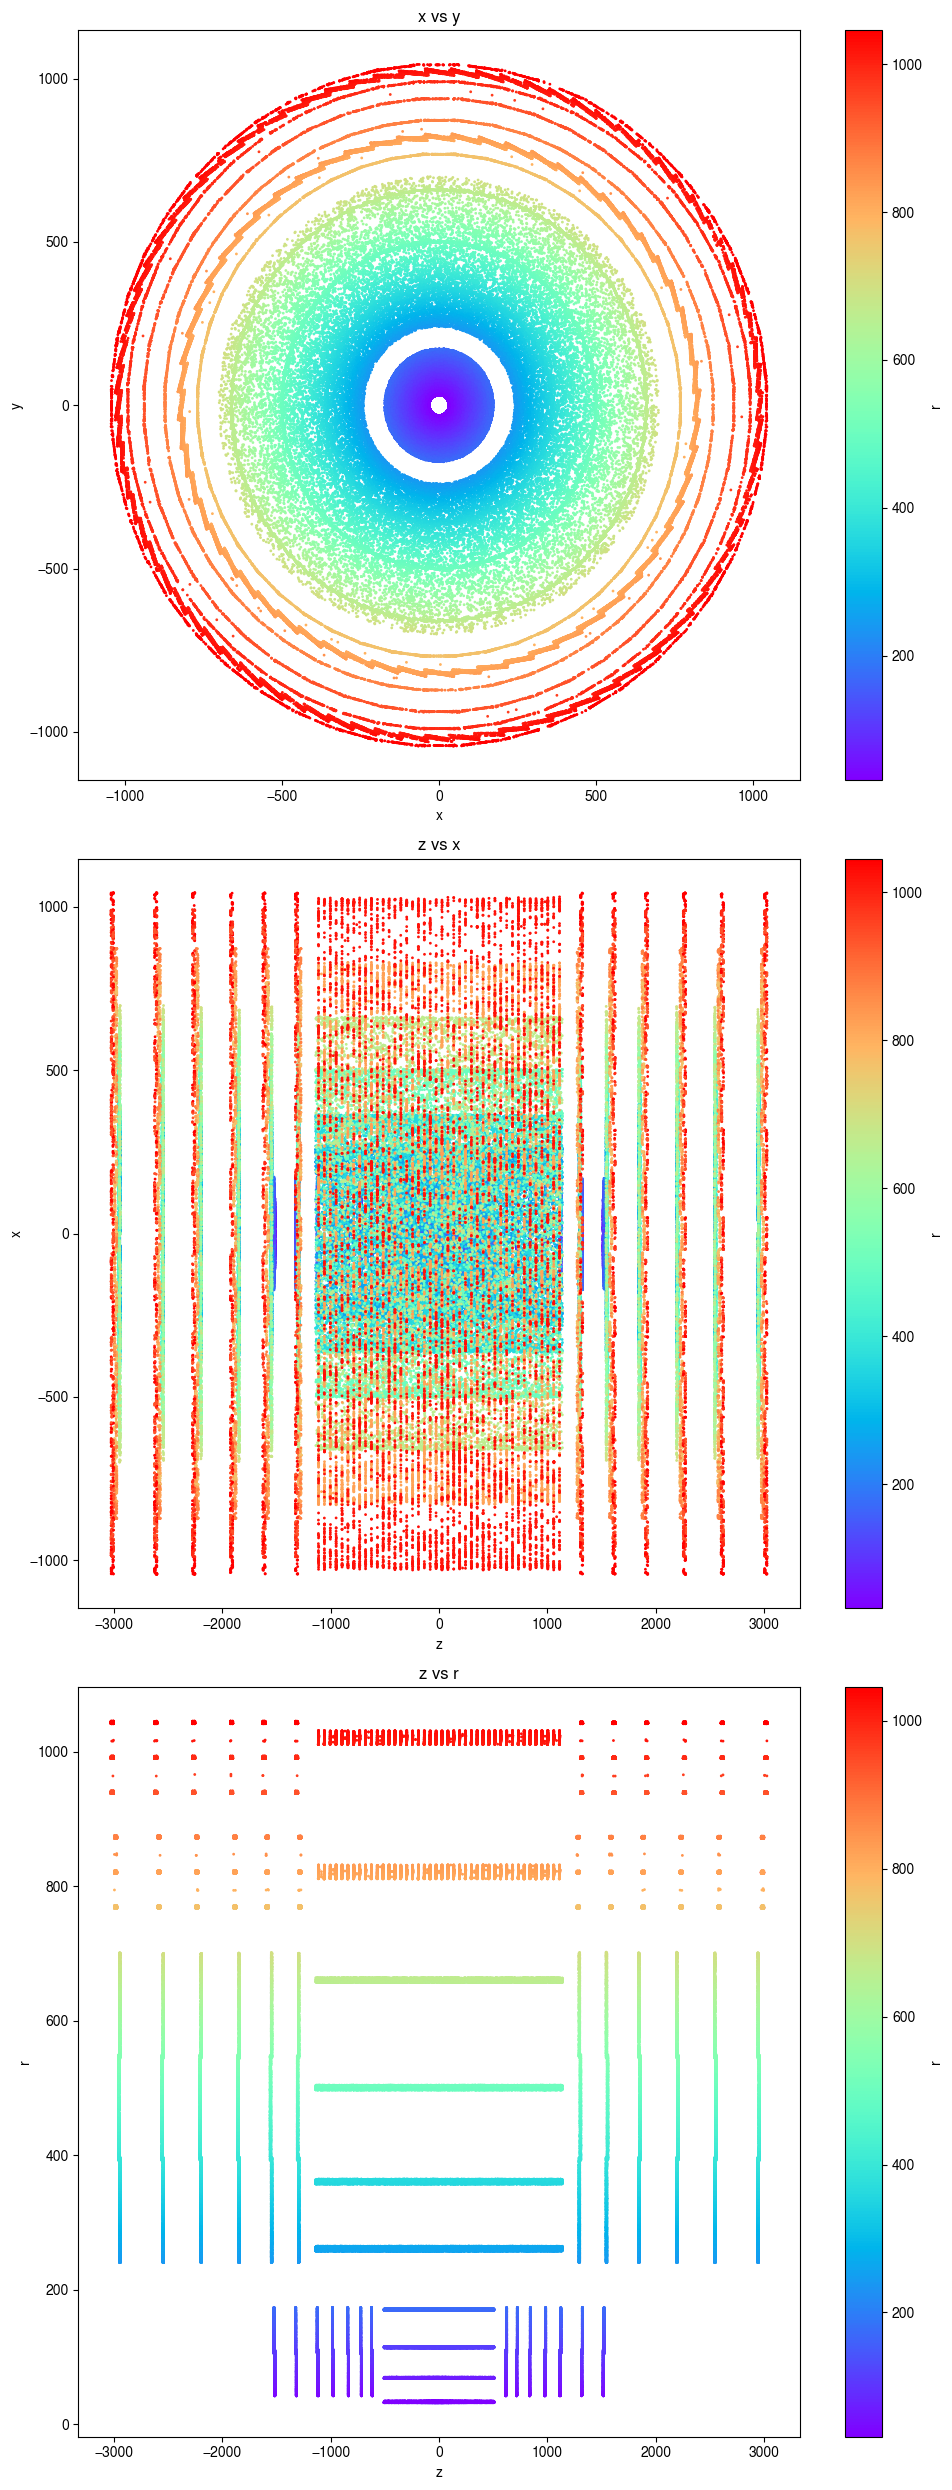

In [14]:
plt.figure(figsize=(10, 25))

# Calculate r (radial distance from z-axis)
digihits['r'] = np.sqrt(digihits.rec_x**2 + digihits.rec_y**2)

# Create subplots
plt.subplot(3, 1, 1)
plt.scatter(digihits.rec_x, digihits.rec_y, c=digihits.r, cmap='rainbow', s=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('x vs y')
plt.colorbar(label='r')

plt.subplot(3, 1, 2)
plt.scatter(digihits.rec_z, digihits.rec_x, c=digihits.r, cmap='rainbow', s=1)
plt.xlabel('z')
plt.ylabel('x')
plt.title('z vs x')
plt.colorbar(label='r')

plt.subplot(3, 1, 3)
plt.scatter(digihits.rec_z, digihits.r, c=digihits.r, cmap='rainbow', s=1)
plt.xlabel('z')
plt.ylabel('r')
plt.title('z vs r')
plt.colorbar(label='r')

plt.tight_layout()

In [41]:
input_particles_file = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/0/particles.root"
digi_particles = load_root_file(input_particles_file, event_id=0, ignore_variable_columns=False)
digi_particles = digi_particles.reset_index(drop=True)

input_simhits_file = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/0/simhits.root"
simhits = load_root_file(input_simhits_file, event_id=0)
simhits = simhits.reset_index(drop=True)

input_digihits_file = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/0/measurements.root"
digihits = load_root_file(input_digihits_file, event_id=0)
digihits = digihits.reset_index(drop=True)

In [42]:
particles = event.get_particles_df()

In [43]:
hits = event.get_tracker_hits_df()

In [44]:
calo_hits = event.get_calo_contributions_df()

In [45]:
digi_particles

,event_id,particle_id,particle_type,process,vx,vy,vz,vt,px,py,...,vertex_primary,vertex_secondary,particle,generation,sub_particle,e_loss,total_x0,total_l0,number_of_hits,outcome
0,0,4503599627370496,413,0,-0.002071,-0.003950,-40.149307,-373.873352,8.362612,-5.792818,...,1,0,0,0,0,22.365232,0.0,0.0,0,0
1,0,4503599627370497,313,0,-0.002071,-0.003950,-40.149307,-373.873352,5.551582,-3.833765,...,1,0,0,0,1,0.000000,0.0,0.0,0,0
2,0,4503599627370498,-311,0,-0.002071,-0.003950,-40.149307,-373.873352,1.093668,0.147071,...,1,0,0,0,2,0.000000,0.0,0.0,0,0
3,0,4503599627370499,-211,0,-0.002071,-0.003950,-40.149307,-373.873352,1.041120,-2.201525,...,1,0,0,0,3,4.084134,0.0,0.0,11,0
4,0,4503599627370500,213,0,-0.002071,-0.003950,-40.149307,-373.873352,1.218392,-1.988743,...,1,0,0,0,4,0.000000,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82835,0,905392849892344261,11,0,-47.749573,-320.650299,1842.503784,29301.808594,-0.000090,-0.000423,...,201,154,0,3,453,0.000476,0.0,0.0,2,0
82836,0,905392849892344262,11,0,-46.229919,-426.554230,2545.861328,33254.269531,0.000180,-0.001465,...,201,154,0,3,454,0.001290,0.0,0.0,2,0
82837,0,905396148427161901,-211,0,5.574176,50.942642,619.227478,-943.589478,0.384727,0.449388,...,201,157,0,2,301,2.268601,0.0,0.0,10,0
82838,0,905396148427161902,2212,0,5.574176,50.942642,619.227478,-943.589478,-0.346143,-0.278581,...,201,157,0,2,302,0.116091,0.0,0.0,6,0


In [46]:
hits

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,detector,r,R,phi,theta,eta,pt
0,32572495965238,-0.963299,0.147280,0,-157.487501,-65.112804,494.886301,-0.547808,-0.280240,-0.381788,0.000246,75542,PixelBarrelReadout,170.417106,523.406573,-2.749548,0.331638,1.787634,0.615327
1,233783760929846,50.415062,0.153074,0,117.938744,-122.682898,-70.942169,-0.281891,0.022450,0.025040,0.000038,75534,PixelBarrelReadout,170.178262,184.373079,-0.805112,1.965760,-0.405653,0.282784
2,255912573285942,51.091908,0.185743,0,-56.984219,-159.959914,-54.833470,-0.248053,-0.135591,0.025030,0.000061,75534,PixelBarrelReadout,169.806877,178.440704,-1.913020,1.883143,-0.317553,0.282693
3,274189890634550,57.653564,0.167487,0,105.784508,-133.749948,103.407970,-0.263430,0.011583,0.025443,0.000057,75534,PixelBarrelReadout,170.526862,199.430737,-0.901621,1.025682,0.574308,0.263685
4,12710587152438,58.232319,0.236361,0,-41.749744,-166.118898,117.954378,-0.233934,-0.121639,0.024350,0.000073,75534,PixelBarrelReadout,171.284937,207.970587,-1.817021,0.967732,0.643339,0.263669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219854,16372415365214,17.419518,0.006257,0,418.240992,636.908977,2995.425660,0.000003,-0.000028,0.000072,0.000023,767295,LongStripEndcapReadout,761.957067,3090.817603,0.989744,0.249091,2.077896,0.000028
219855,17450452189518,9305.426758,0.448383,0,-514.934393,900.034244,2625.461308,0.000162,0.000061,0.000334,0.000399,767356,LongStripEndcapReadout,1036.927707,2822.811746,2.090469,0.376146,1.659036,0.000173
219856,16698833969486,22.526438,0.423192,0,-703.165350,748.241429,2620.489805,0.000006,0.000016,0.000011,0.000002,769306,LongStripEndcapReadout,1026.794403,2814.475718,2.325148,0.373446,1.666411,0.000017
219857,16694539002190,22.526484,0.015981,0,-703.105586,748.407528,2620.606458,0.000027,-0.000063,0.000076,0.000039,769307,LongStripEndcapReadout,1026.874526,2814.613561,2.324994,0.373457,1.666380,0.000069


In [47]:
digihits

,event_nr,volume_id,layer_id,surface_id,extra_id,rec_loc0,rec_loc1,rec_time,var_loc0,var_loc1,...,true_y,true_z,true_incident_phi,true_incident_theta,residual_loc0,residual_loc1,residual_time,pull_loc0,pull_loc1,pull_time
0,0,16,4,1,1,-6.157263,9.142366,1943.355103,0.000225,0.000225,...,6.141427,-1515.599976,-1.514424,-1.429259,NaN,NaN,NaN,NaN,NaN,NaN
1,0,16,4,1,1,10.659911,1.448549,918.387512,0.000225,0.000225,...,-10.681760,-1515.599976,-1.551154,-0.902074,NaN,NaN,NaN,NaN,NaN,NaN
2,0,16,4,1,1,4.341345,-7.520905,1886.475952,0.000225,0.000225,...,-4.323568,-1515.599976,-1.566773,-1.524895,NaN,NaN,NaN,NaN,NaN,NaN
3,0,16,4,1,1,-1.430858,-32.760902,2616.504883,0.000225,0.000225,...,1.428968,-1515.599976,-1.573160,-1.544116,NaN,NaN,NaN,NaN,NaN,NaN
4,0,16,4,1,1,-7.073105,-24.502256,2428.030273,0.000225,0.000225,...,7.081636,-1515.599976,-1.578116,-1.536269,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219844,0,30,12,192,2,6.083471,NaN,NaN,0.005184,NaN,...,902.562805,3009.584473,-2.545888,-1.814547,NaN,NaN,NaN,NaN,NaN,NaN
219845,0,30,12,192,2,-2.631008,NaN,NaN,0.005184,NaN,...,909.995117,3009.500000,1.310152,1.251583,NaN,NaN,NaN,NaN,NaN,NaN
219846,0,30,12,192,2,-3.022058,NaN,NaN,0.005184,NaN,...,910.261169,3009.500000,1.508313,1.181749,NaN,NaN,NaN,NaN,NaN,NaN
219847,0,30,12,192,2,29.838690,NaN,NaN,0.005184,NaN,...,973.045288,3009.500000,-2.456054,-0.374192,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
digihits.columns

Index(['event_nr', 'volume_id', 'layer_id', 'surface_id', 'extra_id',
       'rec_loc0', 'rec_loc1', 'rec_time', 'var_loc0', 'var_loc1', 'var_time',
       'rec_x', 'rec_y', 'rec_z', 'clus_size', 'clus_size_loc0',
       'clus_size_loc1', 'true_loc0', 'true_loc1', 'true_phi', 'true_theta',
       'true_qop', 'true_time', 'true_x', 'true_y', 'true_z',
       'true_incident_phi', 'true_incident_theta', 'residual_loc0',
       'residual_loc1', 'residual_time', 'pull_loc0', 'pull_loc1',
       'pull_time'],
      dtype='object')

In [48]:
simhits

,event_id,geometry_id,particle_id,tx,ty,tz,tt,tpx,tpy,tpz,...,deltapx,deltapy,deltapz,deltae,index,volume_id,boundary_id,layer_id,approach_id,sensitive_id
0,0,1152921779484754177,27322863950365283,85.155350,6.141427,-1515.599976,1948.002319,0.208838,-0.082708,-1.465630,...,0.0,0.0,0.0,-0.000040,-1,16,0,4,0,1
1,0,1152921779484754177,319755573543438331,77.465927,-10.681760,-1515.599976,900.330200,0.002710,-0.000067,-0.003429,...,0.0,0.0,0.0,-0.000128,-1,16,0,4,0,1
2,0,1152921779484754177,59058068062864339,68.480820,-4.323568,-1515.599976,1890.152222,1.350134,-0.118258,-29.393183,...,0.0,0.0,0.0,-0.000035,-1,16,0,4,0,1
3,0,1152921779484754177,432345564227633340,43.270275,1.428968,-1515.599976,2634.140137,0.279906,0.024788,-10.488797,...,0.0,0.0,0.0,-0.000096,-1,16,0,4,0,1
4,0,1152921779484754177,387309567953928282,51.512718,7.081636,-1515.599976,2394.710938,0.307587,0.065187,-8.905021,...,0.0,0.0,0.0,-0.000046,-1,16,0,4,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219854,0,2161728645771608066,680443765965718923,380.635742,902.562805,3009.584473,139188.843750,-0.009319,0.001944,-0.006363,...,0.0,0.0,0.0,-0.000015,-1,30,0,12,0,192
219855,0,2161728645771608066,869376147501547650,374.153015,909.995117,3009.500000,4587.248047,0.003656,0.002089,0.009916,...,0.0,0.0,0.0,-0.000081,-1,30,0,12,0,192
219856,0,2161728645771608066,869376147501547649,373.923492,910.261169,3009.500000,4587.262695,0.002686,0.004646,0.012941,...,0.0,0.0,0.0,-0.000080,-1,30,0,12,0,192
219857,0,2161728645771608066,756631125677441107,433.711945,973.045288,3009.500000,4440.714844,-0.001586,0.021129,-0.007501,...,0.0,0.0,0.0,-0.000273,-1,30,0,12,0,192


In [24]:
particles.columns

Index(['event_id', 'particle_id', 'particle_type', 'process', 'vx', 'vy', 'vz',
       'vt', 'px', 'py', 'pz', 'm', 'q', 'eta', 'phi', 'pt', 'p',
       'vertex_primary', 'vertex_secondary', 'particle', 'generation',
       'sub_particle', 'e_loss', 'total_x0', 'total_l0', 'number_of_hits',
       'outcome'],
      dtype='object')

In [28]:
particles

,event_id,particle_id,particle_type,process,vx,vy,vz,vt,px,py,...,vertex_primary,vertex_secondary,particle,generation,sub_particle,e_loss,total_x0,total_l0,number_of_hits,outcome
0,0,4503599627370496,413,0,-0.002071,-0.003950,-40.149307,-373.873352,8.362612,-5.792818,...,1,0,0,0,0,22.365232,0.0,0.0,0,0
1,0,4503599627370497,313,0,-0.002071,-0.003950,-40.149307,-373.873352,5.551582,-3.833765,...,1,0,0,0,1,0.000000,0.0,0.0,0,0
2,0,4503599627370498,-311,0,-0.002071,-0.003950,-40.149307,-373.873352,1.093668,0.147071,...,1,0,0,0,2,0.000000,0.0,0.0,0,0
3,0,4503599627370499,-211,0,-0.002071,-0.003950,-40.149307,-373.873352,1.041120,-2.201525,...,1,0,0,0,3,4.084134,0.0,0.0,11,0
4,0,4503599627370500,213,0,-0.002071,-0.003950,-40.149307,-373.873352,1.218392,-1.988743,...,1,0,0,0,4,0.000000,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82835,0,905392849892344261,11,0,-47.749573,-320.650299,1842.503784,29301.808594,-0.000090,-0.000423,...,201,154,0,3,453,0.000476,0.0,0.0,2,0
82836,0,905392849892344262,11,0,-46.229919,-426.554230,2545.861328,33254.269531,0.000180,-0.001465,...,201,154,0,3,454,0.001290,0.0,0.0,2,0
82837,0,905396148427161901,-211,0,5.574176,50.942642,619.227478,-943.589478,0.384727,0.449388,...,201,157,0,2,301,2.268601,0.0,0.0,10,0
82838,0,905396148427161902,2212,0,5.574176,50.942642,619.227478,-943.589478,-0.346143,-0.278581,...,201,157,0,2,302,0.116091,0.0,0.0,6,0


In [16]:
runs = range(10)
for run in runs:
    try:
        edm_input_file = f"/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/{run}/edm4hep.root"
        event = EDM4hepEvent(edm_input_file, event_index=0)
    except Exception as e:
        print(f"Error loading event {run}: {e}")
        continue

Loading event 0 from /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/0/edm4hep.root...
  Loaded 772413 particles.
  Loaded 219859 tracker hits.
  Loaded 1122313 calo hits and 5335732 contributions.
Error: 'events' tree not found in /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/1/edm4hep.root
Error loading event 1: Failed to load event 0 from /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/1/edm4hep.root.
Loading event 0 from /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/2/edm4hep.root...
  Loaded 927555 particles.
  Loaded 247078 tracker hits.
  Loaded 1306427 calo hits and 6365761 contributions.
Loading event 0 from /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/3/edm4hep.root...
  Loaded 779885 particles.
  Loaded 219726 tracker hits.
  Loaded 1114860 calo hits and 5354637 contributions.
Loading event 0 fro